In [47]:
from google.colab import drive

drive.mount(
    '/content/drive',
    force_remount=True
)

Mounted at /content/drive


In [48]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/GARBAGE DATASET.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("extract berhasil")

extract berhasil


In [49]:
import os

print(os.listdir('/content/dataset/GARBAGE DATASET'))

['metal', 'food_scraps', 'trash', 'paper', 'glass', 'cardboard', 'plastic']


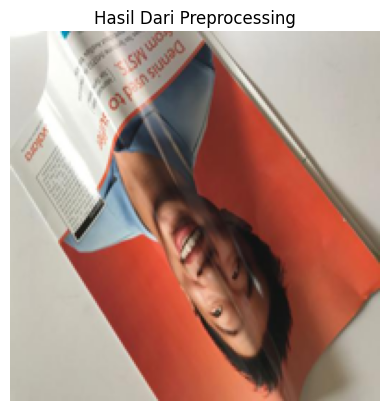

In [50]:
# preprocessing
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img_path = '/content/dataset/GARBAGE DATASET/paper/paper9.jpg'
img = Image.open(img_path)
img = img.resize((200, 200))
img = img.convert('RGB')
img_np = np.array(img)
img_np = img_np[:, :, :3]
pixels = img_np.reshape(-1, 3)
plt.figure()
plt.title("Hasil Dari Preprocessing")
plt.imshow(img)
plt.axis("off")
plt.show()

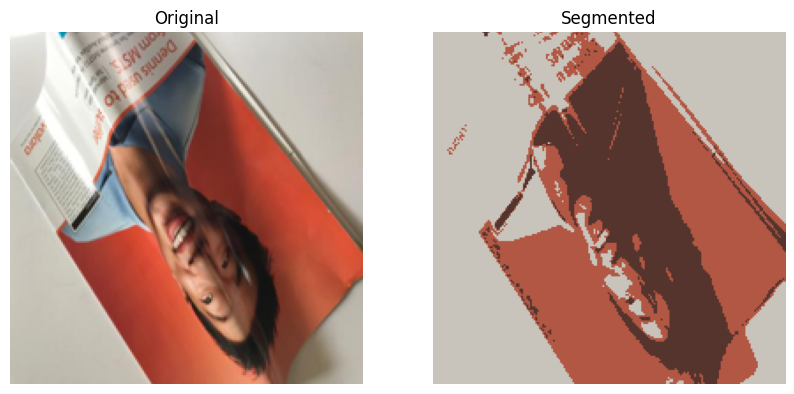

In [51]:
#segmentasi citra dengan k-means
k = 3
np.random.seed(42)
centroids = pixels[np.random.choice(len(pixels), k, replace=False)]

def dist(a, b):
    return np.sqrt(np.sum((a - b)**2))

converged = False
while not converged:
    labels = []

    for p in pixels:
        distances = []
        for c in centroids:
            distances.append(dist(p, c))
        labels.append(np.argmin(distances))
    labels = np.array(labels)

    old_centroids = centroids.copy()
    new_centroids = []

    for i in range(k):
        cluster_pixels = pixels[labels == i]
        if len(cluster_pixels) > 0:
            new_centroids.append(np.mean(cluster_pixels, axis=0))
        else:
            new_centroids.append(centroids[i])

    new_centroids = np.array(new_centroids)
    if np.allclose(old_centroids, new_centroids):
        converged = True
    else:
        centroids = new_centroids

segmented_pixels = centroids[labels]
segmented_img = segmented_pixels.reshape(img_np.shape).astype(np.uint8)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Segmented")
plt.imshow(segmented_img)
plt.axis("off")

plt.show()

In [53]:
import os
import numpy as np
from PIL import Image

PATH_FOLDER = '/content/dataset/GARBAGE DATASET'

X_train_rgb = []
y_train = []

labels = [f for f in os.listdir(PATH_FOLDER) if os.path.isdir(os.path.join(PATH_FOLDER, f))]
print(f"Menemukan {len(labels)} kelas/label sampah di dalam dataset.\n")

for label_idx, label_name in enumerate(labels):
    folder_path = os.path.join(PATH_FOLDER, label_name)

    list_gambar = [f for f in os.listdir(folder_path) if f.endswith('.jpg')][:100]

    print(f"Ekstraksi fitur RGB untuk folder [{label_name}] berisi {len(list_gambar)} gambar")

    for filename in list_gambar:
        full_path = os.path.join(folder_path, filename)

        img = Image.open(full_path).resize((200, 200)).convert('RGB')
        img_np = np.array(img)[:, :, :3]
        pixels = img_np.reshape(-1, 3)

        k = 3
        np.random.seed(42)
        centroids = pixels[np.random.choice(len(pixels), k, replace=False)]

        iterasi = 0
        converged = False
        while not converged:
             distances = np.linalg.norm(pixels[:, np.newaxis] - centroids, axis=2)
             img_labels = np.argmin(distances, axis=1)

             old_centroids = centroids.copy()
             centroids = np.array([pixels[img_labels == i].mean(axis=0) if len(pixels[img_labels == i]) > 0 else centroids[i] for i in range(k)])
             if np.allclose(old_centroids, centroids):
                  converged = True
        iterasi += 1

        segmented_pixels = centroids[img_labels]
        segmented_img = segmented_pixels.reshape(img_np.shape).astype(np.uint8)

        mean_r = np.mean(segmented_img[:, :, 0])
        mean_g = np.mean(segmented_img[:, :, 1])
        mean_b = np.mean(segmented_img[:, :, 2])

        features = np.array([mean_r, mean_g, mean_b])
        features = features.astype(int)

        X_train_rgb.append(features)
        y_train.append(label_idx)

X_train_rgb = np.array(X_train_rgb)
y_train = np.array(y_train)

print("\nEKSTRAKSI SELESAI ")
print(f"Total gambar yang berhasil diekstrak : {len(X_train_rgb)}")
print(f"Ukuran Matriks Fitur : {X_train_rgb.shape}")

Menemukan 7 kelas/label sampah di dalam dataset.

Ekstraksi fitur RGB untuk folder [metal] berisi 100 gambar
Ekstraksi fitur RGB untuk folder [food_scraps] berisi 100 gambar
Ekstraksi fitur RGB untuk folder [trash] berisi 100 gambar
Ekstraksi fitur RGB untuk folder [paper] berisi 100 gambar
Ekstraksi fitur RGB untuk folder [glass] berisi 100 gambar
Ekstraksi fitur RGB untuk folder [cardboard] berisi 100 gambar
Ekstraksi fitur RGB untuk folder [plastic] berisi 100 gambar

EKSTRAKSI SELESAI 
Total gambar yang berhasil diekstrak : 700
Ukuran Matriks Fitur : (700, 3)


In [54]:
import pandas as pd

df = pd.DataFrame(X_train_rgb, columns=['R', 'G', 'B'])
df['label'] = y_train
df.to_csv('/content/hasil_ekstraksi_sampah.csv', index=False)
print("Selesai! File sudah masuk ke folder Colab.")

Selesai! File sudah masuk ke folder Colab.


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_split, y_test = train_test_split(
    X_train_rgb,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Jumlah data training :", X_train.shape)
print("Jumlah data testing :", X_test.shape)

Jumlah data training : (560, 3)
Jumlah data testing : (140, 3)



Euclidean
Accuracy : 0.3357142857142857
Confusion Matrix:
 [[4 2 8 1 2 2 1]
 [1 9 2 2 2 3 1]
 [1 1 6 3 6 1 2]
 [3 2 3 5 1 2 4]
 [2 2 5 2 5 3 1]
 [3 2 1 1 2 9 2]
 [3 1 3 3 1 0 9]]


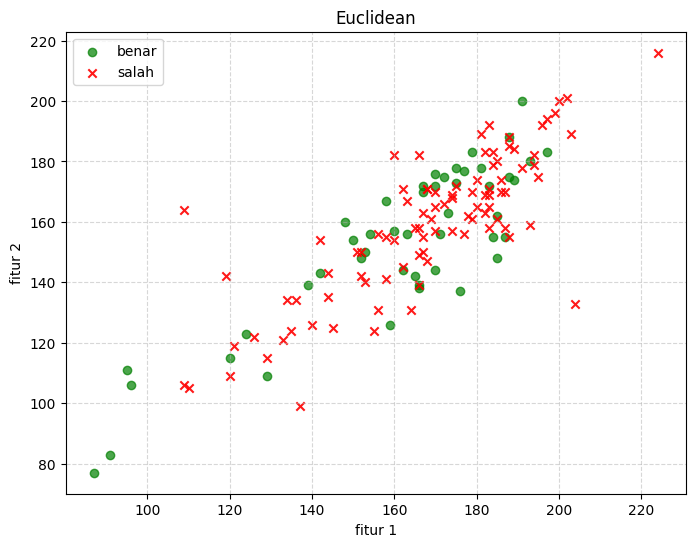


Manhattan
Accuracy : 0.3142857142857143
Confusion Matrix:
 [[4 2 8 2 3 0 1]
 [1 8 1 2 2 5 1]
 [0 2 8 3 5 0 2]
 [4 2 2 5 2 2 3]
 [2 3 4 2 4 2 3]
 [3 3 1 1 3 8 1]
 [4 1 2 4 2 0 7]]


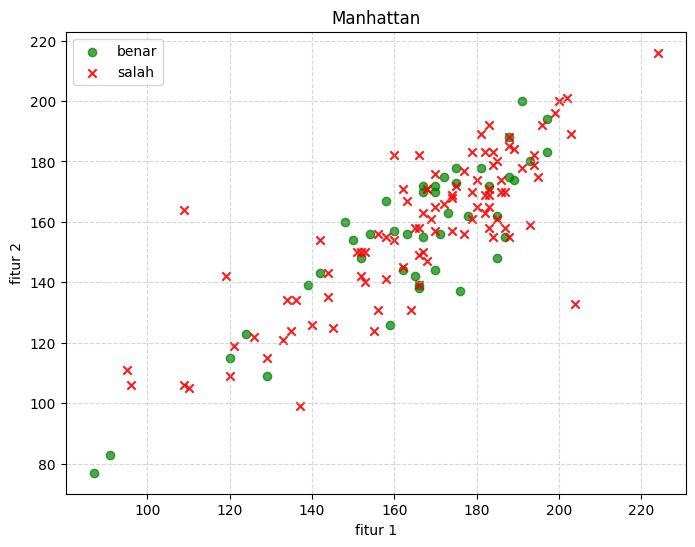


Cosine
Accuracy : 0.30714285714285716
Confusion Matrix:
 [[5 4 6 1 0 2 2]
 [1 9 2 1 5 2 0]
 [1 2 7 1 6 3 0]
 [4 0 1 5 3 2 5]
 [5 2 1 2 3 2 5]
 [5 3 1 2 1 7 1]
 [4 2 1 2 3 1 7]]


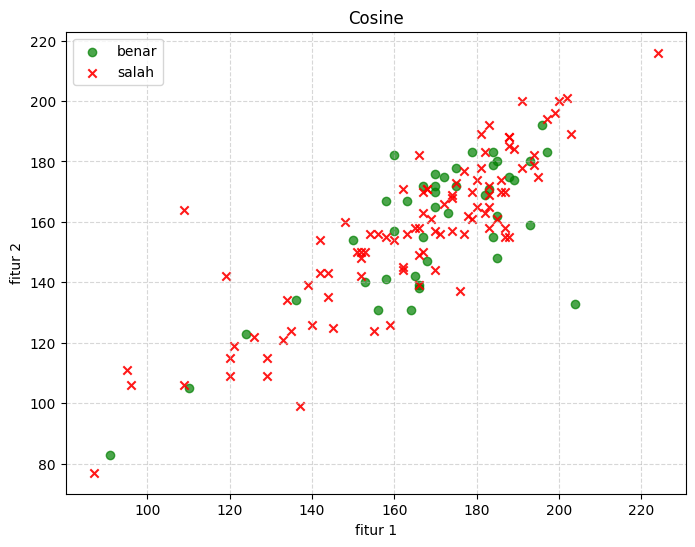

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix

def euclidean(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

def manhattan(x1, x2):
    return np.sum(np.abs(x1 - x2))

def cosine(x1, x2):
    dot_prod = np.dot(x1, x2)
    norm_x1 = np.linalg.norm(x1)
    norm_x2 = np.linalg.norm(x2)
    return 1 - (dot_prod / (norm_x1 * norm_x2))

def knn_predict(X_train, y_train, X_test, k, distance_type):
    predictions = []

    for x in X_test:
        distances = []

        for i, x_tr in enumerate(X_train):
            if distance_type == "euclidean":
                d = euclidean(x, x_tr)
            elif distance_type == "manhattan":
                d = manhattan(x, x_tr)
            elif distance_type == "cosine":
                d = cosine(x, x_tr)

            distances.append((d, y_train[i]))

        distances.sort(key=lambda x: x[0])
        k_neighbors = distances[:k]
        labels = [label for _, label in k_neighbors]

        most_common = Counter(labels).most_common(1)[0][0]
        predictions.append(most_common)

    return np.array(predictions)

def evaluate_and_plot(y_test, y_pred, X_test, title):
    acc = np.sum(y_test == y_pred) / len(y_test)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{title}")
    print("Accuracy :", acc)
    print("Confusion Matrix:\n", cm)

    plt.figure(figsize=(8, 6))

    correct = (y_test == y_pred)
    plt.scatter(X_test[correct, 0], X_test[correct, 1], c='green', marker='o', label="benar", alpha=0.7)

    wrong = (y_test != y_pred)
    plt.scatter(X_test[wrong, 0], X_test[wrong, 1], c='red', marker='x', label="salah", alpha=0.9)

    plt.title(title)
    plt.xlabel("fitur 1")
    plt.ylabel("fitur 2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

y_pred_euc = knn_predict(X_train, y_train_split, X_test, 3, "euclidean")
evaluate_and_plot(y_test, y_pred_euc, X_test, "Euclidean")

y_pred_man = knn_predict(X_train, y_train_split, X_test, 3, "manhattan")
evaluate_and_plot(y_test, y_pred_man, X_test, "Manhattan")

y_pred_cos = knn_predict(X_train, y_train_split, X_test, 3, "cosine")
evaluate_and_plot(y_test, y_pred_cos, X_test, "Cosine")

In [65]:
X_train.shape

(560, 3)

In [66]:
X_test.shape

(140, 3)

In [68]:
y_train.shape

(700,)

In [69]:
y_test.shape

(140,)


Rekap Hasil Tindakan 3R Data 10-38
Rekomendasi_3R
Recycle (Daur Ulang)           12
Reuse (Gunakan Kembali)         8
Recycle (Bikin Kompos)          5
Reduce (Kurangi Penggunaan)     4


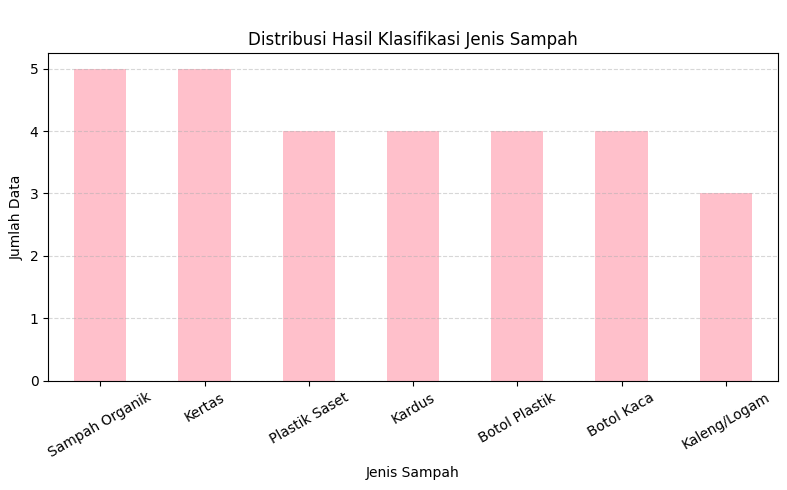


Hasil Interpretasi 3R Satu Sampel
Jenis Sampah : Plastik Saset
Rekomendasi 3R : Reduce (Kurangi Penggunaan)


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

aturan_sampah = {
    0: {"nama": "Kertas", "aksi": "Recycle (Daur Ulang)"},
    1: {"nama": "Kardus", "aksi": "Recycle (Daur Ulang)"},
    2: {"nama": "Botol Kaca", "aksi": "Reuse (Gunakan Kembali)"},
    3: {"nama": "Kaleng/Logam", "aksi": "Recycle (Daur Ulang)"},
    4: {"nama": "Botol Plastik", "aksi": "Reuse (Gunakan Kembali)"},
    5: {"nama": "Plastik Saset", "aksi": "Reduce (Kurangi Penggunaan)"},
    6: {"nama": "Sampah Organik", "aksi": "Recycle (Bikin Kompos)"}
}

y_pred_terpilih = y_pred_euc

nama_kelas_pred = [peta_sampah[label]["nama"] for label in y_pred_terpilih]
aksi_3r_pred = [peta_sampah[label]["aksi"] for label in y_pred_terpilih]

df_hasil = pd.DataFrame({'Prediksi_Kelas': nama_kelas_pred,'Rekomendasi_3R': aksi_3r_pred})
awal = 10
akhir = 39
sampel = df_hasil.iloc[awal:akhir]
print(f"\nRekap Hasil Tindakan 3R Data {awal}-{akhir-1}")
rekap_3r = sampel['Rekomendasi_3R'].value_counts()
print(rekap_3r.to_string())
rekap_kelas = sampel['Prediksi_Kelas'].value_counts()

plt.figure(figsize=(8,5))
rekap_kelas.plot(kind='bar',color='pink')
plt.title("\nDistribusi Hasil Klasifikasi Jenis Sampah")
plt.xlabel("Jenis Sampah")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=30)
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

print("\nHasil Interpretasi 3R Satu Sampel")
idx = awal
label_pred = y_pred_terpilih[idx]

print("Jenis Sampah :",peta_sampah[label_pred]["nama"])
print("Rekomendasi 3R :",peta_sampah[label_pred]["aksi"])